# **1. GAN**
GAN(Generative Adversarial Network)은 생성자(Generator)와 판별자(Discriminator)라는 두 신경망이 경쟁하며 학습하는 구조입니다. 생성자는 무작위 노이즈로부터 실제와 구분하기 어려운 데이터를 만들어내고, 판별자는 입력된 데이터가 진짜(실제 데이터)인지 가짜(생성자 출력)인지 구별하려 합니다. 학습 과정에서 생성자는 판별자를 속이도록 점점 더 현실적인 데이터를 만들고, 판별자는 더 정밀하게 구분하도록 발전하여, 최종적으로는 매우 사실적인 이미지나 데이터 생성이 가능해집니다.
<img src="./images/GAN.png" width=500>

- Generator(G, 생성자): 랜덤한 숫자 z를 받아서 진짜처럼 보이는 가짜 데이터 만듬
- Discriminator(D, 판별자): 입력된 데이터가 실제 데이터인지 생성자가 만든 가짜인지 구별

> 둘이 번갈아 학습하면서 생성자는 점점 더 진짜 같은 데이터를 만들게 됨

> GAN은 정답 이미지 하나를 그대로 외워서 복사하는 모델이 아니라 학습 데이터의 분포와 특징을 학습하여 새로운 샘플을 생성 하는 거시 목표

### 1. GAN의 학습 방법
- 생성자는 처음에는 아무것도 모르므로 랜덤 노이즈에서 이상한 이미지를 만듬
- 실제 데이터에는 보이지 않는 데이터 분포 p_data가 있음.
- 학습이 진행되면 생성자가 만드는 분포 p_g가 실제 데이터 분포 p_data와 비슷해지는 방향으로 이동

> GNN의 핵심 목표는 특정 이미지 한 장을 맞히는 것보다 실제 데이터가 만들어지는 분포를 흉내 내는 것

### 두 모델을 번갈아 학습
1. 판별자 D 학습
    - 판별자는 실제 이미지에는 1, 가짜 이미지에는 0을 출력하도록 학습
    ```
        실제 이미지 x > D(x) : 1에 가깝게
        가짜 이미지 G(z) > D(G(z)) : 0에 가깝게
    ```

2. 생성자 G 학습
    - 생성자의 목표는 판별자를 속이는 것
    - 생성된 이미지를 D에 넣었을 때 D가 1(진짜)이라고 판단하게 만들도록 G를 업데이트 함
    ```
        z > G(z) > D(G(z)) > 1에 가깝게 만들기
    ```

> 1은 생성 이미지가 실제 정답이라는 뜻이 아니라, G가 D를 속이기 위해 원하는 목표값

### LOSS 구하기
- 판별자는 이진 분류 문제이므로 BCE(Binary Cross Entropy)를 사용
    - 실제 이미지 > target 1
    - 가짜 이미지 > target 0
    - 생성자를 학습할 때 > D가 가짜를 1이라고 판단하도록 target 1

- BCEWithLogitsLoss()을 사용 > Sigmoid + BCE를 하나로 계산
    - Discriminator 마지막 출력 = logit(확률 아님) > BCEWithLogitsLoss > loss

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.xpu.is_available():
    DEVICE = torch.device('xpu')
else:
    DEVICE = torch.device('cpu')

print(DEVICE)

cpu


In [ ]:
BATCH_SIZE = 128

transform = transforms.Compose([
    transforms.ToTensor(), # 0~255 사이의 값을 0~1 사이로 변환
    transforms.Normalize((0.5,), (0.5,)) # 흑백이라 튜플 안에 값이 하나만 들어감. 컬러면 (0.5, 0.5, 0.5), (0.5, 0.5, 0.5)
    # 0~1 사이의 값을 -1~1 사이로 변환
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4
)

images, labels = next(iter(train_loader))
print("images:", images.shape)
print("min/max:", images.min().item(), images.max().item())

images: torch.Size([128, 1, 28, 28])
min/max: -1.0 1.0


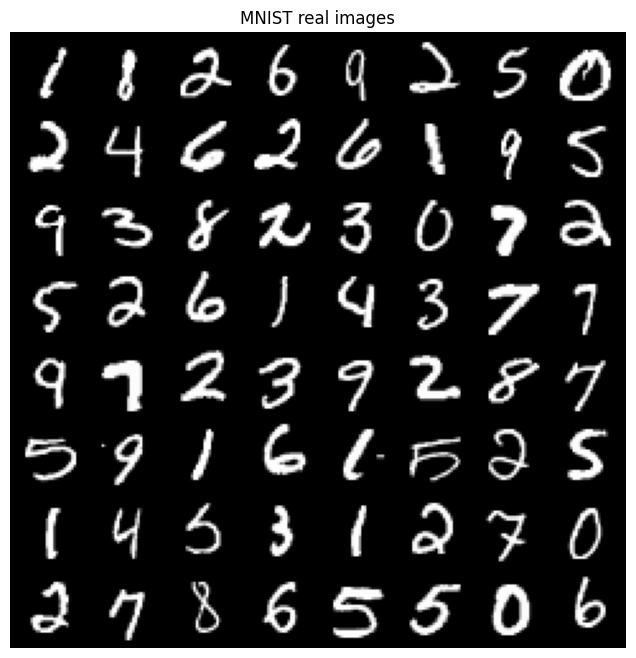

In [3]:
def show_images(images, nrow=8, title=None):
    images = (images.detach().cpu() + 1) / 2
    grid = make_grid(images, nrow=nrow, padding=2)
    plt.figure(figsize=(8, 8))
    if title:
        plt.title(title)
    plt.axis("off")
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    plt.show()

show_images(images[:64], title="MNIST real images")

### 2. Generator
- 생성자의 입력은 이미지가 아니라 z라는 랜덤 벡터
- LATENT_DIM = 100. 이미지 한 장을 만들기 위해 100개의 랜덤 숫자를 넣음
```
    z[B, 100] > Linear > [B, 256] > [B, 512] > [B, 784] > reshape > [B, 1, 28, 28]
    마지막 Tanh는 생성 이미지의 픽셀 범위를 -1 ~ 1로 만듬
```

In [4]:
LATENT_DIM = 100

class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 28 * 28),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.net(z)
        return x.view(-1, 1, 28, 28)

G = Generator(LATENT_DIM).to(DEVICE)

z = torch.randn(8, LATENT_DIM, device=DEVICE)
fake = G(z)
print("noise:", z.shape)
print("fake :", fake.shape)
print("range:", fake.min().item(), fake.max().item())

noise: torch.Size([8, 100])
fake : torch.Size([8, 1, 28, 28])
range: -0.9631475210189819 0.9546797275543213


### 3. Discriminator
- 판별자는 이미지를 받아 샘플마다 숫자 하나(logit)를 출력
```
[B, 1, 28, 28] > Flatten > [B, 784] > [B, 512] > [B, 256] > [B, 1]
```

In [5]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.net(x)

D = Discriminator().to(DEVICE)

with torch.no_grad():
    logits = D(fake)
    probs = torch.sigmoid(logits)

print("logits:", logits.shape)
print("probabilities:", probs[:5].squeeze())

logits: torch.Size([8, 1])
probabilities: tensor([0.4717, 0.4834, 0.5020, 0.4937, 0.4989])


In [6]:
criterion = nn.BCEWithLogitsLoss()

optimizer_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
optimizer_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))

fixed_noise = torch.randn(64, LATENT_DIM, device=DEVICE)

### 4. GAN 학습
1. D를 학습할 때
    - 실제 이미지 real을 D에 넣고 target을 1로 설정
    - G가 만든 fake를 D에 넣고 target을 0으로 설정
    - 두 loss를 더해서 D만 업데이트함
    - fake.detach()를 사용하여 G는 업데이트하지 않음

2. G를 학습할 때
    - 새로운 noise로 fake 이미지를 만듬
    - D(fake)를 계산
    - target을 1로 둠. D가 fake를 진짜라고 판단하도록 G를 학습
    - G만 업데이트

Epoch [01/20] D_loss: 0.9476 | G_loss: 1.4346


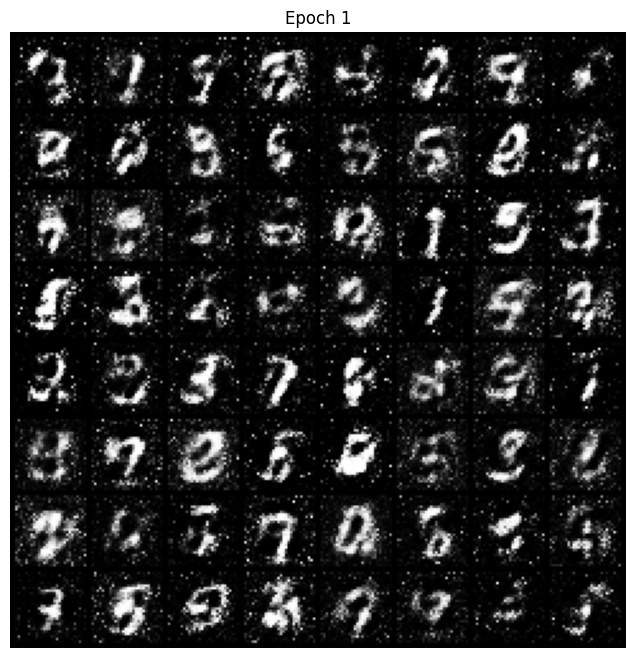

Epoch [02/20] D_loss: 1.0126 | G_loss: 1.3146


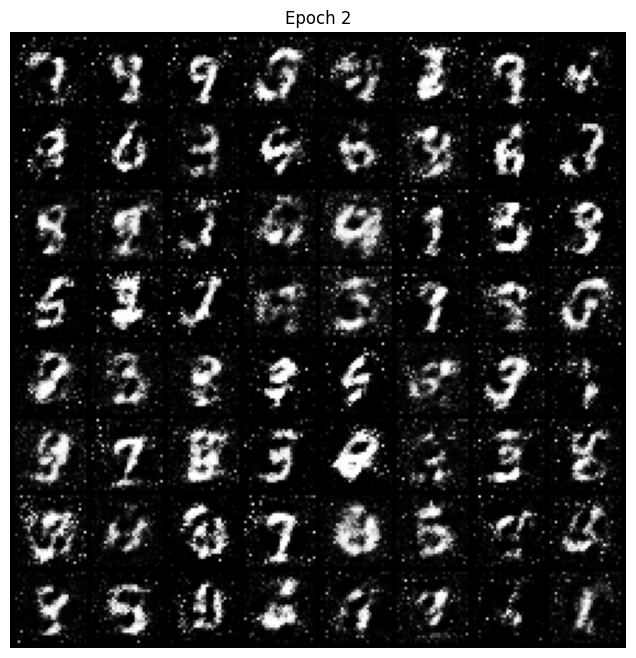

Epoch [03/20] D_loss: 1.0615 | G_loss: 1.4117


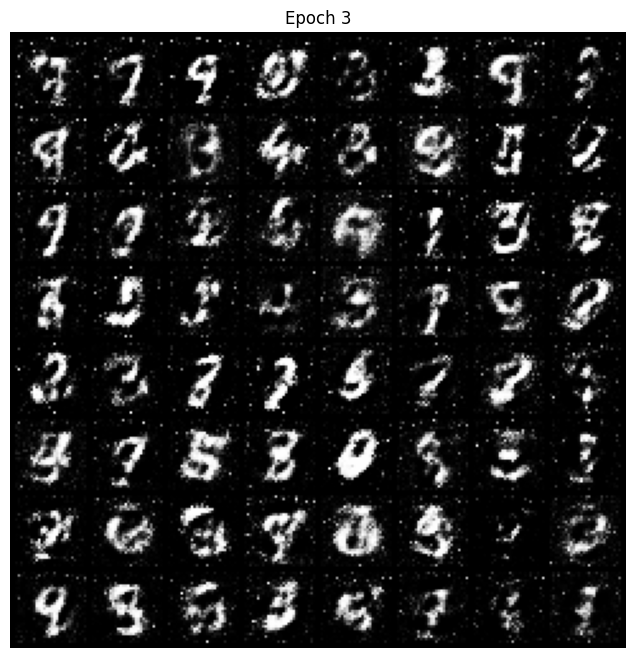

Epoch [04/20] D_loss: 1.0127 | G_loss: 1.0232


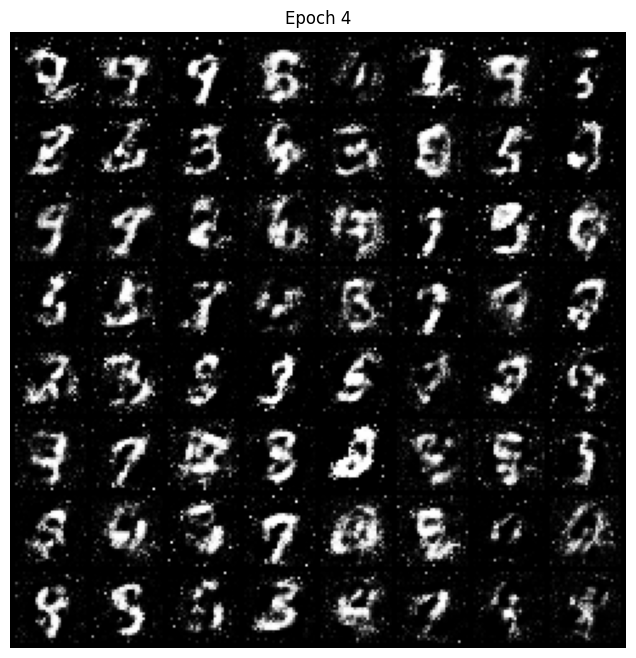

Epoch [05/20] D_loss: 1.0629 | G_loss: 1.1450


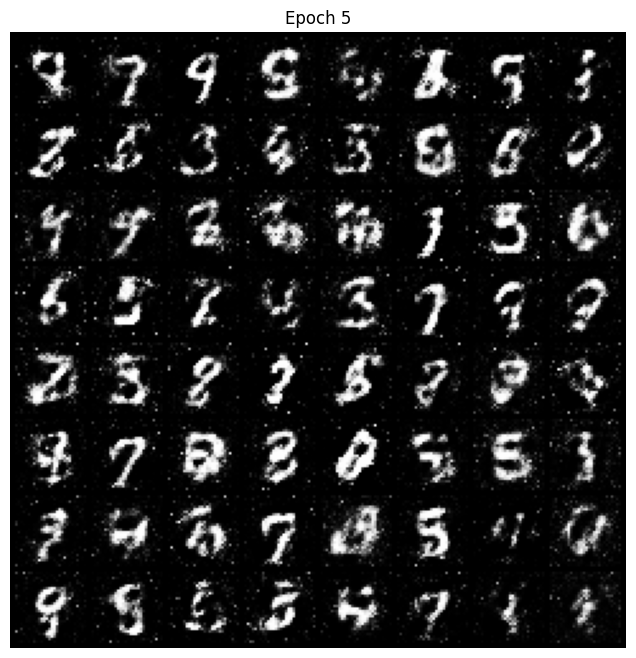

Epoch [06/20] D_loss: 1.3046 | G_loss: 0.8906


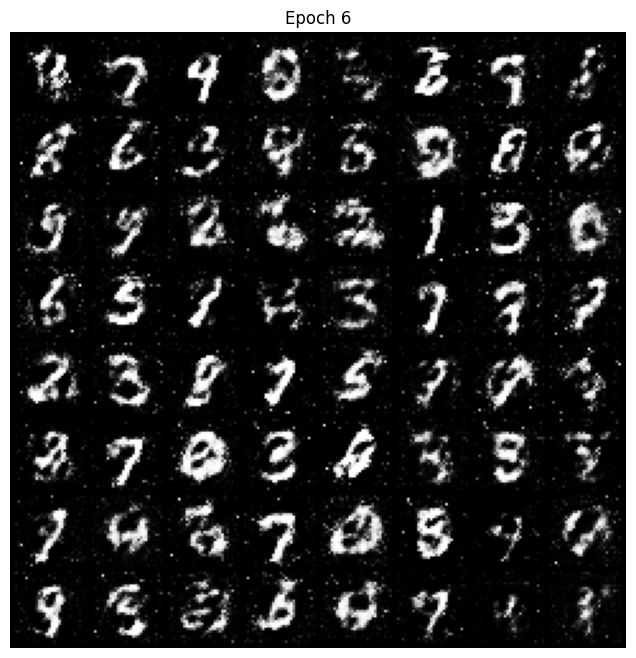

Epoch [07/20] D_loss: 1.0810 | G_loss: 0.8891


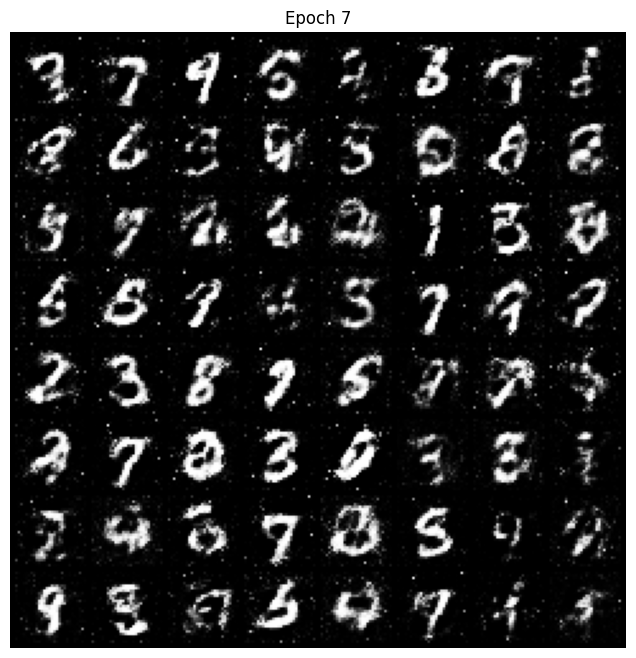

Epoch [08/20] D_loss: 1.0439 | G_loss: 1.3125


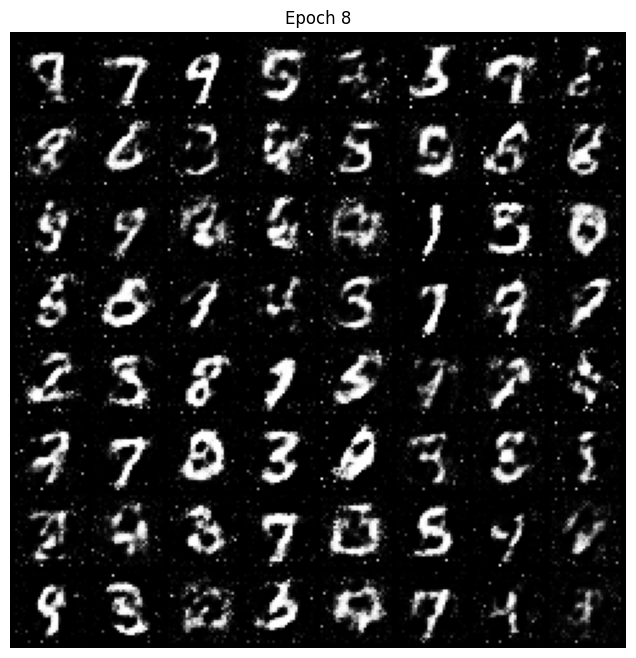

Epoch [09/20] D_loss: 1.0644 | G_loss: 1.1658


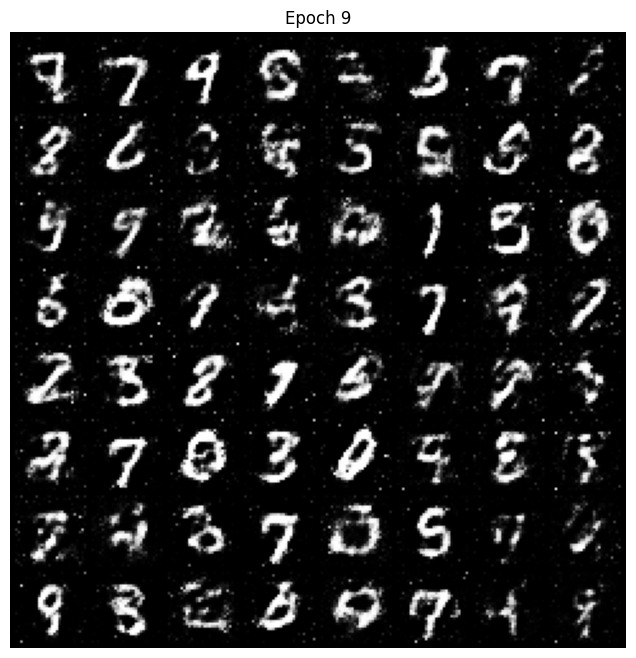

Epoch [10/20] D_loss: 1.1724 | G_loss: 0.7850


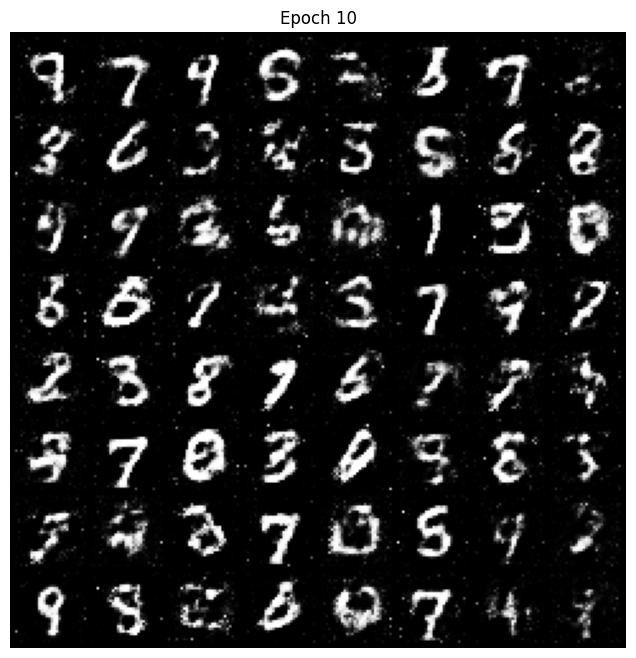

Epoch [11/20] D_loss: 1.2312 | G_loss: 1.5347


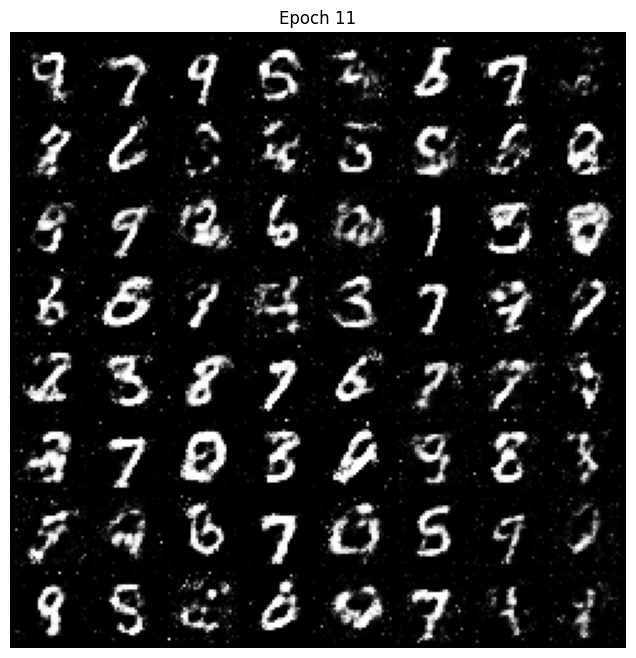

Epoch [12/20] D_loss: 1.1226 | G_loss: 1.1729


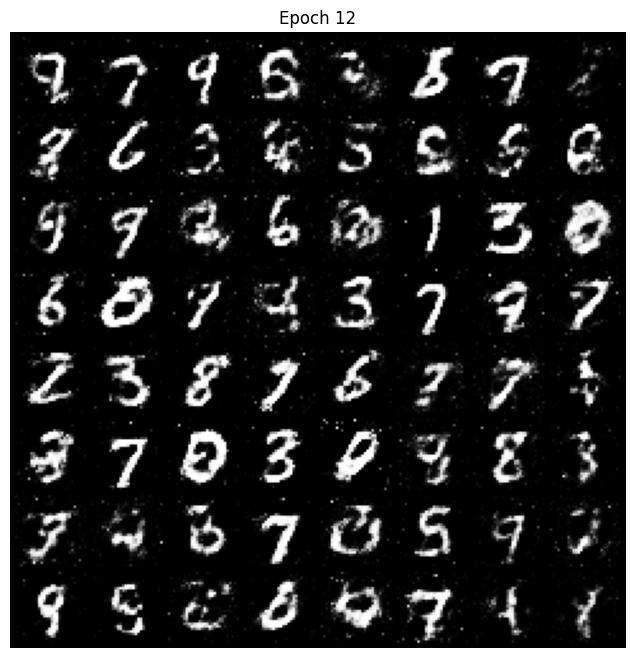

Epoch [13/20] D_loss: 1.2130 | G_loss: 0.6910


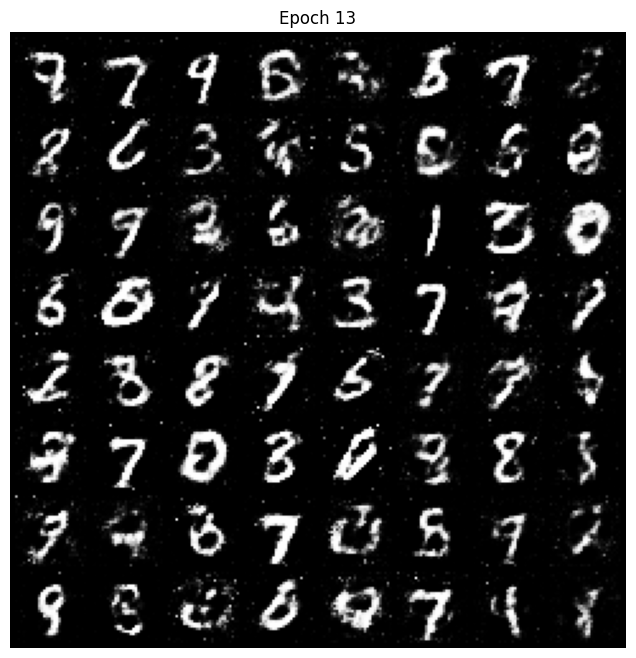

Epoch [14/20] D_loss: 1.1101 | G_loss: 0.8717


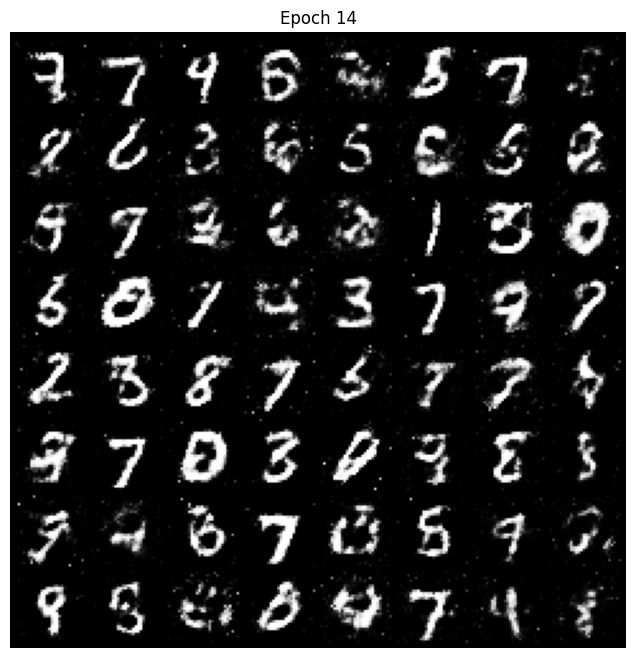

Epoch [15/20] D_loss: 1.1463 | G_loss: 1.2229


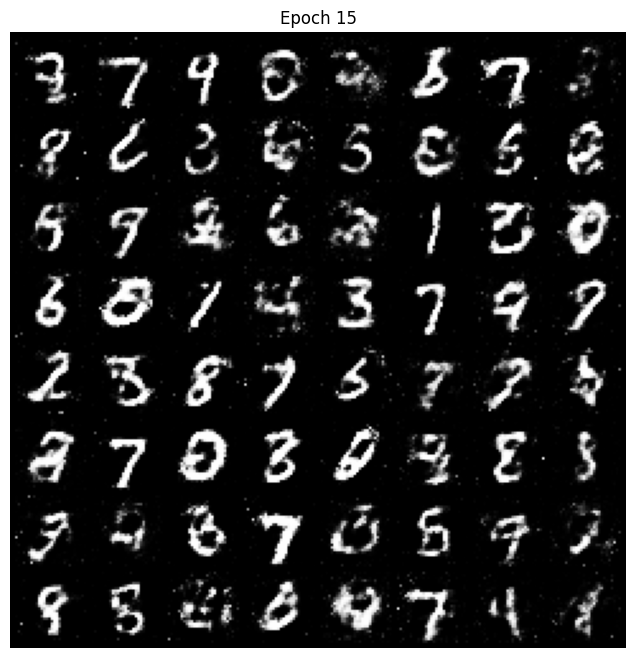

Epoch [16/20] D_loss: 1.0945 | G_loss: 1.2735


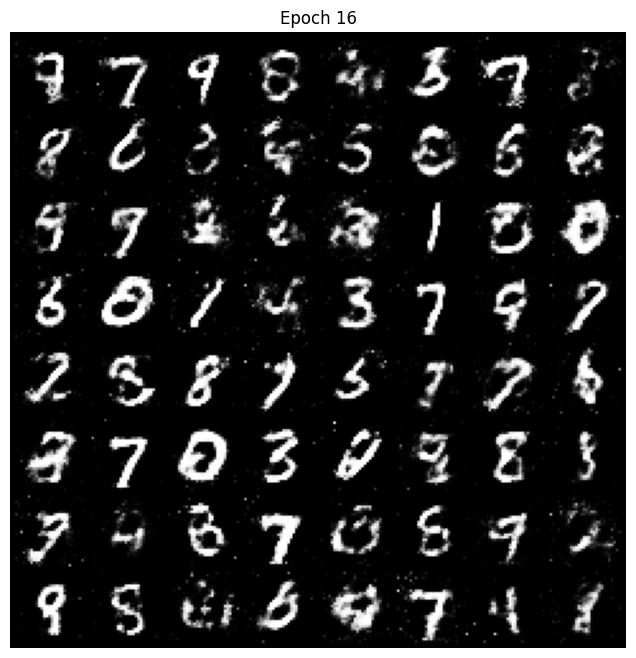

Epoch [17/20] D_loss: 1.2222 | G_loss: 1.2657


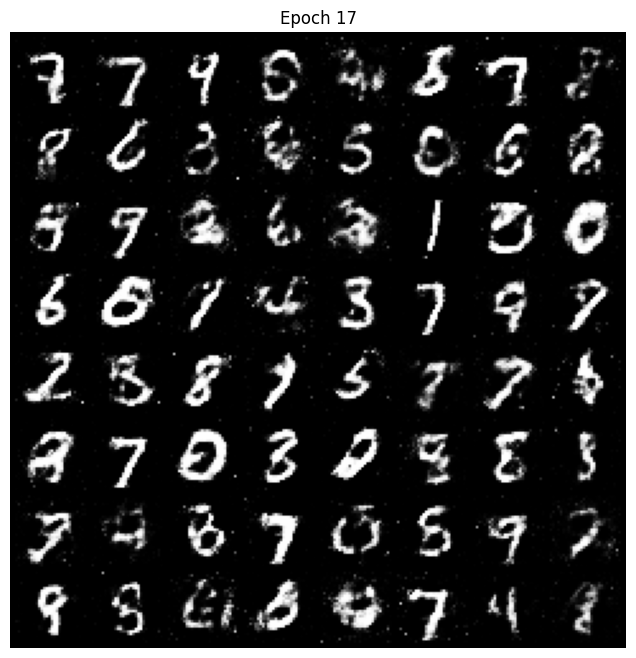

Epoch [18/20] D_loss: 1.2312 | G_loss: 0.8644


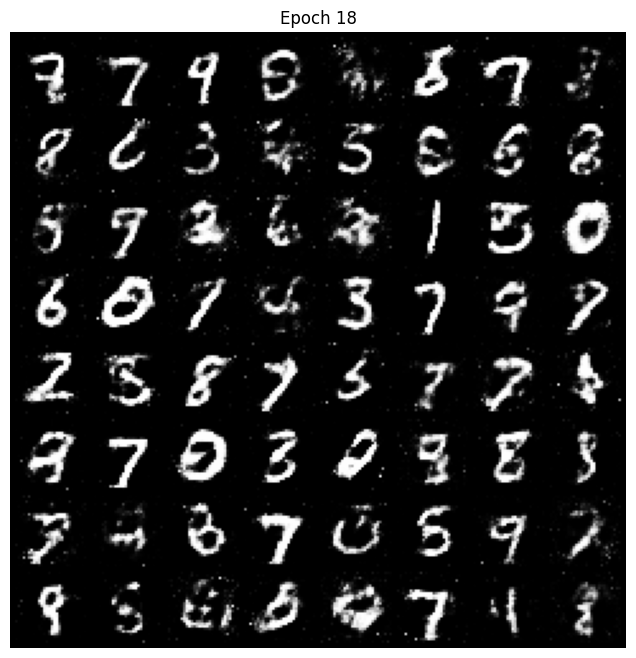

Epoch [19/20] D_loss: 1.1227 | G_loss: 0.9988


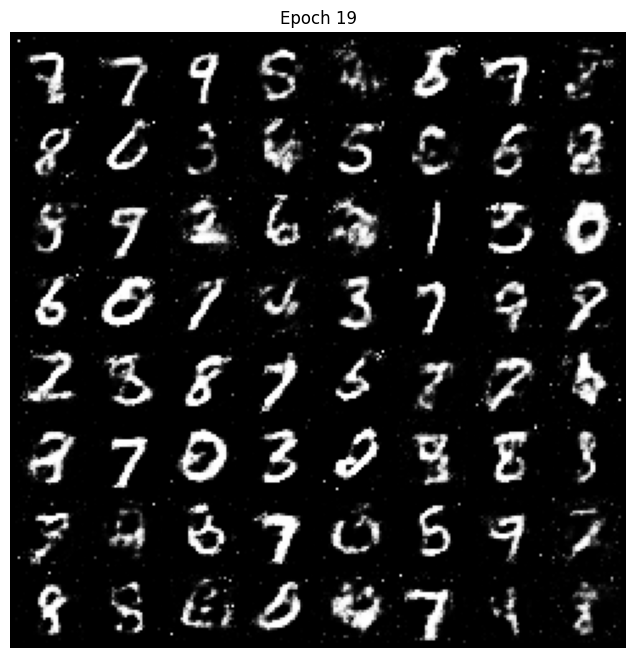

Epoch [20/20] D_loss: 1.2089 | G_loss: 0.6321


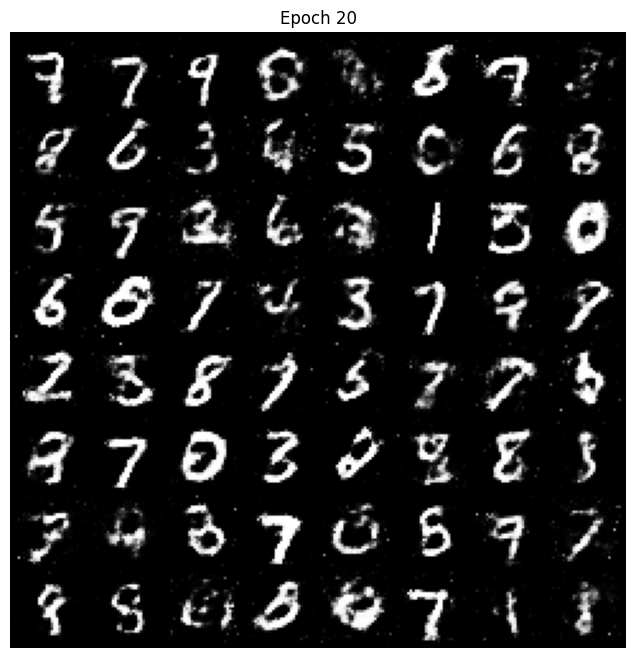

In [8]:
def train_gan(G, D, train_loader, epochs=20):
    g_losses = []
    d_losses = []

    for epoch in range(1, epochs + 1):
        for batch_idx, (real, _) in enumerate(train_loader):
            real = real.to(DEVICE)
            batch_size = real.size(0)


            # discriminator 학습
            optimizer_D.zero_grad()

            real_logits = D(real)
            real_targets = torch.ones_like(real_logits)
            d_real_loss = criterion(real_logits, real_targets)

            z = torch.randn(batch_size, LATENT_DIM, device=DEVICE)
            fake = G(z)
            fake_logits = D(fake.detach())  # G로 gradient 전달 차단
            fake_targets = torch.zeros_like(fake_logits)
            d_fake_loss = criterion(fake_logits, fake_targets)

            d_loss = d_real_loss + d_fake_loss
            d_loss.backward()
            optimizer_D.step()


            # generator 학습
            optimizer_G.zero_grad()

            z = torch.randn(batch_size, LATENT_DIM, device=DEVICE)
            fake = G(z)
            fake_logits = D(fake)

            # G의 목표: D가 fake를 1(진짜)이라고 판단하게 만들기
            g_targets = torch.ones_like(fake_logits)
            g_loss = criterion(fake_logits, g_targets)

            g_loss.backward()
            optimizer_G.step()



            d_losses.append(d_loss.item())
            g_losses.append(g_loss.item())

        with torch.no_grad():
            samples = G(fixed_noise)

        print(
            f"Epoch [{epoch:02d}/{epochs}] "
            f"D_loss: {d_loss.item():.4f} | G_loss: {g_loss.item():.4f}"
        )
        show_images(samples, title=f"Epoch {epoch}")

    return g_losses, d_losses

g_losses, d_losses = train_gan(G, D, train_loader, epochs=20)

### 5. Loss 그래프를 볼 때 주의할 점
- 일반 분류에서는 loss가 계속 낮아지면 좋음
- GAN에서는 두 모델이 서로 경쟁하므로 G loss와 D loss가 단순하게 계속 감소하지 않을 수 있음
- 아래 내용을 확인해야 함
    - 고정된 noise에서 생성 이미지가 시간이 지나며 좋아지는가?
    - 거의 똑같은 이미지만 반복 생성하지 않는가? (Mode Collapse)
    - D가 지나치게 강해져 G가 전혀 배우고 있지 않은지?
    - 실무에서는 FID 같은 생성 품질 지표 사용

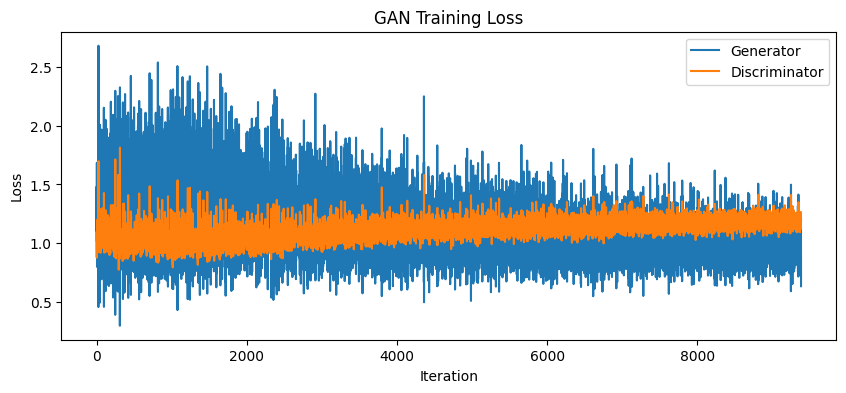

In [9]:
plt.figure(figsize=(10, 4))
plt.plot(g_losses, label="Generator")
plt.plot(d_losses, label="Discriminator")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("GAN Training Loss")
plt.legend()
plt.show()